### Bridge DAS

In [1]:
import sys
import numpy as np
from pathlib import Path

sys.path.append('..')

from src.plot import plot_das_wavefield, plot_das_psd, plot_das_psd_2d

In [2]:
# 1. Define paths 
bridge_dir = Path('..') / 'data' / 'raw_bridge'

# Grab the first processed bridge files
bridge_files = sorted(bridge_dir.glob('*_bridge.npz'))
das_paths = bridge_files[:1]

if not das_paths:
    raise FileNotFoundError(f"No _bridge.npz files found in {bridge_dir}")

for p in das_paths:
    print(f"Found: {p.name}")

Found: 20250723_205000_bridge.npz


In [3]:
# 2. Load the first file
das_data = np.load(das_paths[0])

print("\nKeys inside .npz file:")
for key in das_data:
    print(f' - {key}')


Keys inside .npz file:
 - data
 - dt
 - dx
 - start_sample
 - end_sample


In [4]:
# 3. Extract data and natively saved metadata
raw_array = das_data['data']
dt = float(das_data['dt'])           # Natively extracted (0.004s)
dx = float(das_data['dx'])           # Natively extracted (2.45m)
fs = 1.0 / dt

N = raw_array.shape[1]               # Number of time samples
num_channels = raw_array.shape[0]    # Number of channels

In [5]:
# 4. PREPROCESSING: Zero-mean the data (DC Offset Removal)
das_array = raw_array 

# 5. Create t_axis and x_axis ON THE FLY
t_axis = np.arange(N) * dt             # Time in seconds
x_axis = np.arange(num_channels) * dx  # Distance in METERS for bridge scale

print(f"\nDAS array shape: {das_array.shape} (Channels x Time)")
print(f"Time axis shape: {t_axis.shape}")
print(f"Channel axis shape: {x_axis.shape}")
print(f"Total duration: {(N * dt) / 60:.2f} minutes")
print(f"Total bridge length: {x_axis[-1]:.2f} meters")


DAS array shape: (421, 150001) (Channels x Time)
Time axis shape: (150001,)
Channel axis shape: (421,)
Total duration: 10.00 minutes
Total bridge length: 1029.00 meters


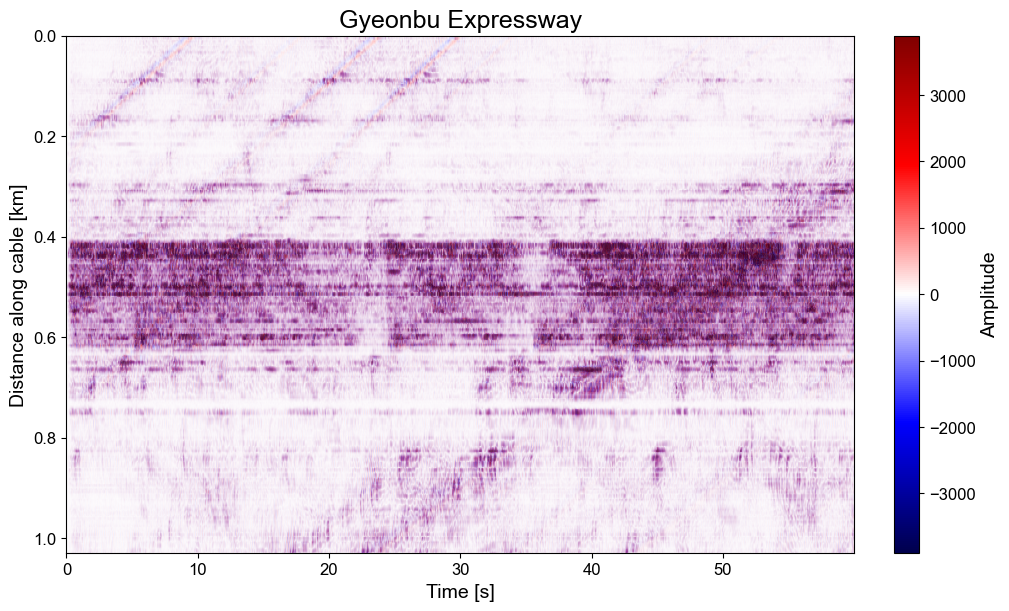

In [6]:
# 6. Plotting
# Distance Calculations
ch_400m = int(400 / dx) # result: 163
ch_600m = int(600 / dx) # result: 244

plot_das_wavefield(
    das_array,
    fs=fs,
    dx=dx,
    start_sec=0,
    duration_sec=60,    # Zoom in to 1 minute 
    start_chan=None,#ch_400m,
    end_chan=None,#ch_600m,
    pclip=98,            
    title="Gyeonbu Expressway", 
    figsize=(10, 6)
)

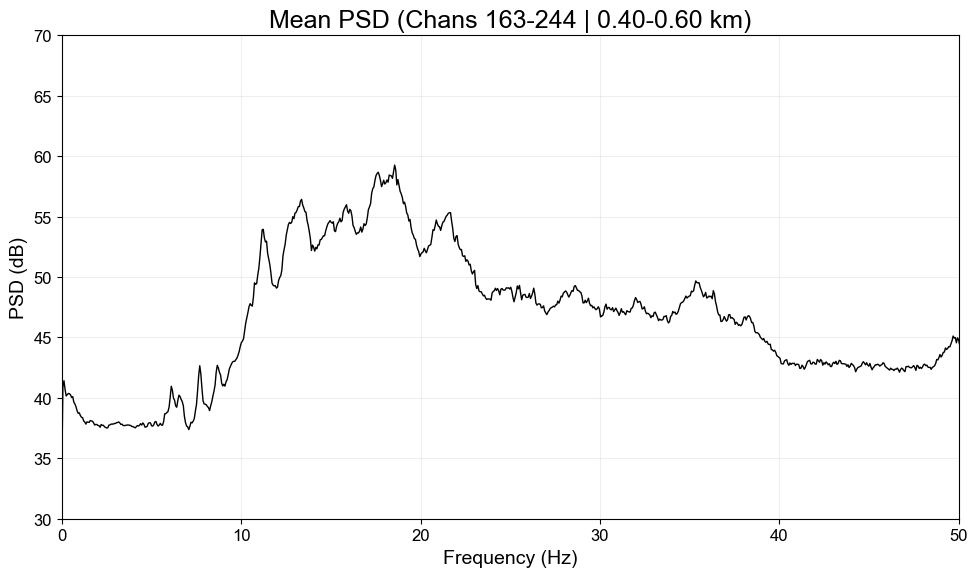

In [7]:
ch_400m = int(400 / dx)  # 163
ch_600m = int(600 / dx)  # 244

plot_das_psd(
    data=das_array,
    fs=fs,
    dx=dx,
    start_chan=ch_400m,
    end_chan=ch_600m,
    nperseg=4096,           # ~16-second windows (excellent frequency resolution for 250 Hz data)
    xlim=(0.0, 50.0),       
    ylim=(30, 70.0),              
    xscale="linear",        # Linear is essential for picking out harmonic bridge modes
    ylabel="PSD (dB)",
    figsize=(10, 6)
)

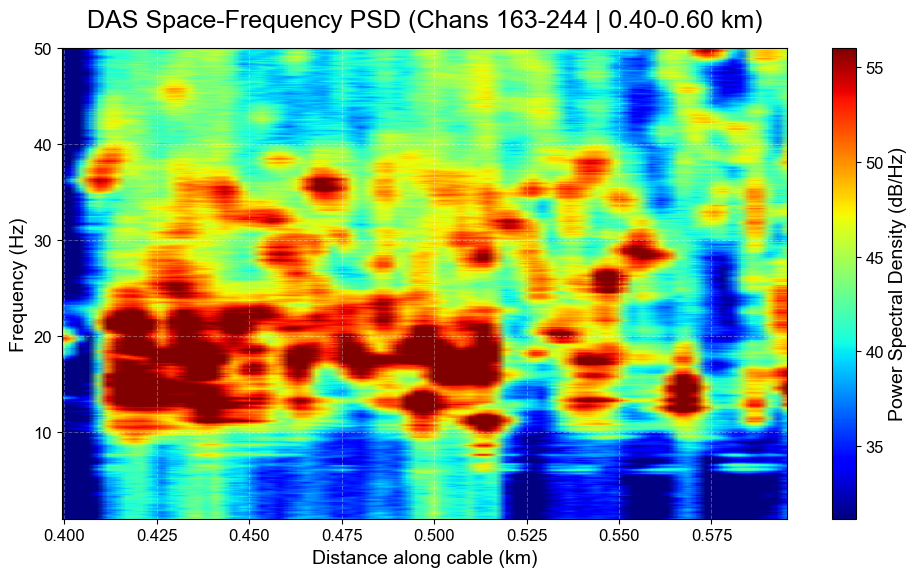

In [8]:
ch_400m = int(400 / dx)  # 163
ch_600m = int(600 / dx)  # 244

plot_das_psd_2d(
    data=das_array,
    fs=fs,
    dx=dx,
    start_chan=ch_400m,
    end_chan=ch_600m,
    nperseg=4096,     
    flim=(1, 50),                            
    figsize=(10, 6)
)